# Script del entrenador

In [1]:
#Se monta el Drive:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

def trainer(ticker, trials=1, FHi='2021-01-01', FHe="", ini=150, peri=10, hori=20, guardar=False, graficar=True):
  '''
  Entrena un modelo Prophet para el ticker especificado usando optimización con Optuna.

  Parámetros:
  - ticker (str): símbolo del activo (ej. 'FUNO11.MX')
  - trials (int): número de iteraciones de búsqueda de hiperparámetros
  - FHi (str): fecha de inicio para descarga de datos (formato 'YYYY-MM-DD')
  - guardar (bool): si se desea guardar el modelo entrenado

  Retorna:
  - modelo (Prophet): objeto Prophet entrenado
  '''
  import time
  start = time.time()

  import yfinance as yf
  import pandas as pd
  import optuna
  import pickle
  import os
  import matplotlib.pyplot as plt
  from datetime import datetime, timedelta
  from prophet import Prophet
  from prophet.diagnostics import cross_validation, performance_metrics


  ticker = ticker.upper()
  ticker_id = ticker.lower().replace('.', '').replace('-', '')
  if FHe == "":
    FHe = datetime.today().strftime('%Y-%m-%d')
  DatAss = yf.download(ticker, start=FHi, end=FHe, auto_adjust=True)['Close']

  df_prophet = DatAss.reset_index().copy()
  df_prophet['ds'] = DatAss.index
  df_prophet['y'] = df_prophet[ticker]
  df_prophet = df_prophet[['ds', 'y']]

  # Definir función objetivo para Optuna
  def objective(trial):

    # Hiperparámetros a optimizar
    growth = trial.suggest_categorical('growth', ['linear', 'logistic'])
    changepoint_prior_scale = trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True)
    seasonality_prior_scale = trial.suggest_float('seasonality_prior_scale', 0.01, 10.0, log=True)
    holidays_prior_scale = trial.suggest_float('holidays_prior_scale', 0.01, 10.0, log=True)
    weekly_seasonality = trial.suggest_categorical('weekly_seasonality', [True, False])

    # Si usamos crecimiento logístico, necesitamos agregar la columna 'cap'
    if growth == 'logistic':
      df_prophet['cap'] = df_prophet['y'].max() * 1.2  # margen superior automático

    # Definir y entrenar modelo
    model = Prophet(
      growth=growth,
      changepoint_prior_scale=changepoint_prior_scale,
      seasonality_prior_scale=seasonality_prior_scale,
      holidays_prior_scale=holidays_prior_scale,
      weekly_seasonality=weekly_seasonality,
      daily_seasonality=True
    )
    model.fit(df_prophet)

    # Validación cruzada temporal
    df_cv = cross_validation(model, initial=f'{ini} days', period=f'{peri} days', horizon=f'{hori} days')
    df_perf = performance_metrics(df_cv)

    # Retornamos el RMSE promedio
    return df_perf['rmse'].mean()

  optuna.logging.set_verbosity(optuna.logging.CRITICAL)
  study = optuna.create_study(direction='minimize')
  study.optimize(objective, n_trials=trials)

  print('Best hiperparameters:')
  print(study.best_params)

  # Definir modelo con hiperparámetros óptimos
  modelo = Prophet(
    **study.best_params,
    daily_seasonality=True
  )
  # Entrenar sobre toda la base
  if study.best_params['growth'] == 'logistic':
    df_prophet['cap'] = df_prophet['y'].max() * 1.2  # margen superior automático

  modelo.fit(df_prophet)

  df_cv = cross_validation(modelo, initial='150 days', period='10 days', horizon='30 days')
  df_perf = performance_metrics(df_cv)
  print(f'🧠 Entrenamiento completado para {ticker} con RMSE promedio: {df_perf["rmse"].mean():.4f}')

  future = modelo.make_future_dataframe(periods=90)
  if study.best_params['growth'] == 'logistic':
    future['cap'] = df_prophet['cap'].iloc[0]

  # Predecir con modelo final
  forecast = modelo.predict(future)

  if graficar:
    modelo.plot(forecast)
    plt.title(f'Price forecast for {ticker}')
    plt.xlabel("Date")
    plt.ylabel("Closure price")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.legend()
    plt.show()

  carpeta_modelos = '/content/drive/MyDrive/Projects/FinTech-ML-Portfolio/2_scripts/'
  if guardar:
    nombre_archivo = f'model_{ticker_id}.pkl'
    ruta = os.path.join(carpeta_modelos, nombre_archivo)

    with open(ruta, 'wb') as f:
      pickle.dump(modelo, f)

    print(f'✅ Modelo guardado en: {ruta}')

  end = time.time()
  hrs = (end - start)//3600
  min = ((end - start)%3600)//60
  seg = (end - start)%60
  print(f'Tiempo de ejecución: {hrs:.0f} horas, {min:.0f} minutos y  {seg:.0f} segundos')
  print("Mejores hiperparámetros:")
  print(study.best_params)
  print(f"RMSE óptimo: {study.best_value:.4f}")
  return modelo

In [4]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 16.5 MB/s eta 0:00:00


[*********************100%***********************]  1 of 1 completed
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/tdlypjhi.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/zwl8e_77.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=95917', 'data', 'file=/tmp/tmpc37ybuhf/tdlypjhi.json', 'init=/tmp/tmpc37ybuhf/zwl8e_77.json', 'output', 'file=/tmp/tmpc37ybuhf/prophet_models64l573g/prophet_model-20250714064729.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:47:29 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:47:30 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 77 forecasts with cutoffs between 2023-06-07 00:00:00 and 2025-07-06 00:00:00


  0%|          | 0/77 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/h3ac5tq_.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/_k8xn1s9.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=85360', 'data', 'file=/tmp/tmpc37ybuhf/h3ac5tq_.json', 'init=/tmp/tmpc37ybuhf/_k8xn1s9.json', 'output', 'file=/tmp/tmpc37ybuhf/prophet_modelx9hkm3rf/prophet_model-20250714064730.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:47:30 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:47:30 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/wnnuozly.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/n_5xyrrc.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

  0%|          | 0/77 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/2kcgvr4u.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/35g0f0za.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=53335', 'data', 'file=/tmp/tmpc37ybuhf/2kcgvr4u.json', 'init=/tmp/tmpc37ybuhf/35g0f0za.json', 'output', 'file=/tmp/tmpc37ybuhf/prophet_modelqca40q10/prophet_model-20250714064755.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:47:55 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:47:55 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/tj_k8mzc.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/zv_dq3ck.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/

...

Best hiperparameters:
{'growth': 'linear', 'changepoint_prior_scale': 0.3481179948778687, 'seasonality_prior_scale': 0.024056286275402513, 'holidays_prior_scale': 8.417130545673885, 'weekly_seasonality': True}


06:52:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
INFO:prophet:Making 75 forecasts with cutoffs between 2023-06-02 00:00:00 and 2025-06-11 00:00:00


  0%|          | 0/75 [00:00<?, ?it/s]

DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/qsze69kl.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/st6xsoa0.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=6168', 'data', 'file=/tmp/tmpc37ybuhf/qsze69kl.json', 'init=/tmp/tmpc37ybuhf/st6xsoa0.json', 'output', 'file=/tmp/tmpc37ybuhf/prophet_modelku29fy7g/prophet_model-20250714065225.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:52:25 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:52:25 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/nvubh1gm.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpc37ybuhf/qb359rc5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/l

🧠 Entrenamiento completado para ADBE con RMSE promedio: 50.7342


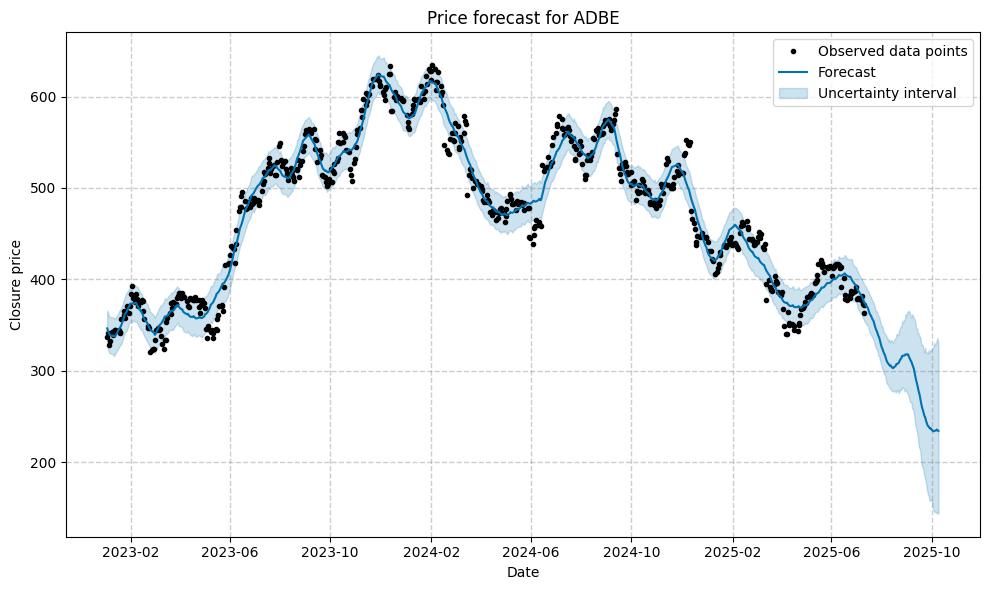

Tiempo de ejecución: 335.51 segundos
Mejores hiperparámetros:
{'growth': 'linear', 'changepoint_prior_scale': 0.3481179948778687, 'seasonality_prior_scale': 0.024056286275402513, 'holidays_prior_scale': 8.417130545673885, 'weekly_seasonality': True}
RMSE óptimo: 24.1164


In [13]:

trainer('ADBE',trials=10, FHi='2023-01-01', hori=5)

In [24]:
trainer('ADBE',trials=55, FHi='2023-01-01', peri=3, hori=5)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
trainer('ADBE',trials=10, FHi='2023-01-01', peri=5, hori=5)

In [5]:
trainer('ADBE',trials=55, FHi='2023-01-01', peri=3, hori=7)

Output hidden; open in https://colab.research.google.com to view.

In [6]:
trainer('ADBE',trials=55, FHi='2023-01-01', peri=3, hori=9)

Output hidden; open in https://colab.research.google.com to view.

In [25]:
trainer('ADBE',trials=55, FHi='2023-01-01', peri=3, hori=10)

Output hidden; open in https://colab.research.google.com to view.

In [26]:
trainer('ADBE',trials=55, FHi='2023-01-01', peri=3, hori=15)

Output hidden; open in https://colab.research.google.com to view.

In [27]:
trainer('ADBE',trials=55, FHi='2023-01-01', peri=3, hori=20)

Output hidden; open in https://colab.research.google.com to view.

In [43]:
code = """
def trainer(ticker, trials=1, FHi='2021-01-01', FHe="", guardar=False, graficar=True):
  '''
  Entrena un modelo Prophet para el ticker especificado usando optimización con Optuna.

  Parámetros:
  - ticker (str): símbolo del activo (ej. 'FUNO11.MX')
  - trials (int): número de iteraciones de búsqueda de hiperparámetros
  - FHi (str): fecha de inicio para descarga de datos (formato 'YYYY-MM-DD')
  - guardar (bool): si se desea guardar el modelo entrenado

  Retorna:
  - modelo (Prophet): objeto Prophet entrenado
  '''

  import yfinance as yf
  import pandas as pd
  import optuna
  import pickle
  import os
  import matplotlib.pyplot as plt
  from datetime import datetime, timedelta
  from prophet import Prophet
  from prophet.diagnostics import cross_validation, performance_metrics

  ticker = ticker.upper()
  ticker_id = ticker.lower().replace('.', '').replace('-', '')
  if FHe == "":
    FHe = datetime.today().strftime('%Y-%m-%d')
  DatAss = yf.download(ticker, start=FHi, end=FHe, auto_adjust=True)['Close']

  df_prophet = DatAss.reset_index().copy()
  df_prophet['ds'] = DatAss.index
  df_prophet['y'] = df_prophet[ticker]
  df_prophet = df_prophet[['ds', 'y']]

  # Definir función objetivo para Optuna
  def objective(trial):

    # Hiperparámetros a optimizar
    growth = trial.suggest_categorical('growth', ['linear', 'logistic'])
    changepoint_prior_scale = trial.suggest_float('changepoint_prior_scale', 0.001, 0.5, log=True)
    seasonality_prior_scale = trial.suggest_float('seasonality_prior_scale', 0.01, 10.0, log=True)
    holidays_prior_scale = trial.suggest_float('holidays_prior_scale', 0.01, 10.0, log=True)
    weekly_seasonality = trial.suggest_categorical('weekly_seasonality', [True, False])

    # Si usamos crecimiento logístico, necesitamos agregar la columna 'cap'
    if growth == 'logistic':
      df_prophet['cap'] = df_prophet['y'].max() * 1.2  # margen superior automático

    # Definir y entrenar modelo
    model = Prophet(
      growth=growth,
      changepoint_prior_scale=changepoint_prior_scale,
      seasonality_prior_scale=seasonality_prior_scale,
      holidays_prior_scale=holidays_prior_scale,
      weekly_seasonality=weekly_seasonality,
      daily_seasonality=True
    )
    model.fit(df_prophet)

    # Validación cruzada temporal
    df_cv = cross_validation(model, initial='150 days', period='10 days', horizon='30 days')
    df_perf = performance_metrics(df_cv)

    # Retornamos el RMSE promedio
    return df_perf['rmse'].mean()

  study = optuna.create_study(direction='minimize')
  study.optimize(objective, n_trials=trials)

  print('Best hiperparameters:')
  print(study.best_params)

  # Definir modelo con hiperparámetros óptimos
  modelo = Prophet(
    **study.best_params,
    daily_seasonality=True
  )
  # Entrenar sobre toda la base
  if study.best_params['growth'] == 'logistic':
    df_prophet['cap'] = df_prophet['y'].max() * 1.2  # margen superior automático

  modelo.fit(df_prophet)

  df_cv = cross_validation(modelo, initial='150 days', period='10 days', horizon='30 days')
  df_perf = performance_metrics(df_cv)
  print(f'🧠 Entrenamiento completado para {ticker} con RMSE promedio: {df_perf["rmse"].mean():.4f}')

  future = modelo.make_future_dataframe(periods=90)
  if study.best_params['growth'] == 'logistic':
    future['cap'] = df_prophet['cap'].iloc[0]

  # Predecir con modelo final
  forecast = modelo.predict(future)

  if graficar:
    modelo.plot(forecast)
    plt.title(f'Price forecast for {ticker}')
    #plt.plot(funo, label='Precio de Cierre')
    plt.xlabel("Date")
    plt.ylabel("Closure price")
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.legend()
    plt.show()

  carpeta_modelos = '/content/drive/MyDrive/Projects/FinTech-ML-Portfolio/2_scripts/'
  if guardar:
    nombre_archivo = f'model_{ticker_id}.pkl'
    ruta = os.path.join(carpeta_modelos, nombre_archivo)

    with open(ruta, 'wb') as f:
      pickle.dump(modelo, f)

    print(f'✅ Modelo guardado en: {ruta}')

  return modelo
"""

with open("/content/drive/MyDrive/Projects/FinTech-ML-Portfolio/2_scripts/trainer.py", "w") as file:
    file.write(code)